In [1]:
import pandas as pd
import h5py
import matplotlib.pyplot as plt
import numpy as np
import corner
from copy import deepcopy
from matplotlib import gridspec
import glob
from tqdm import tqdm
from scipy.stats import dirichlet
import seaborn as sns
from scipy.stats import loguniform


sys.path.append('../')
import populations.bbh_models as read_models


/data/wiay/2297403c/conda_envs/amaze/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
chi_b = [0.,0.1,0.2,0.5]
alpha = [0.2,0.5,1.,2.,5.]

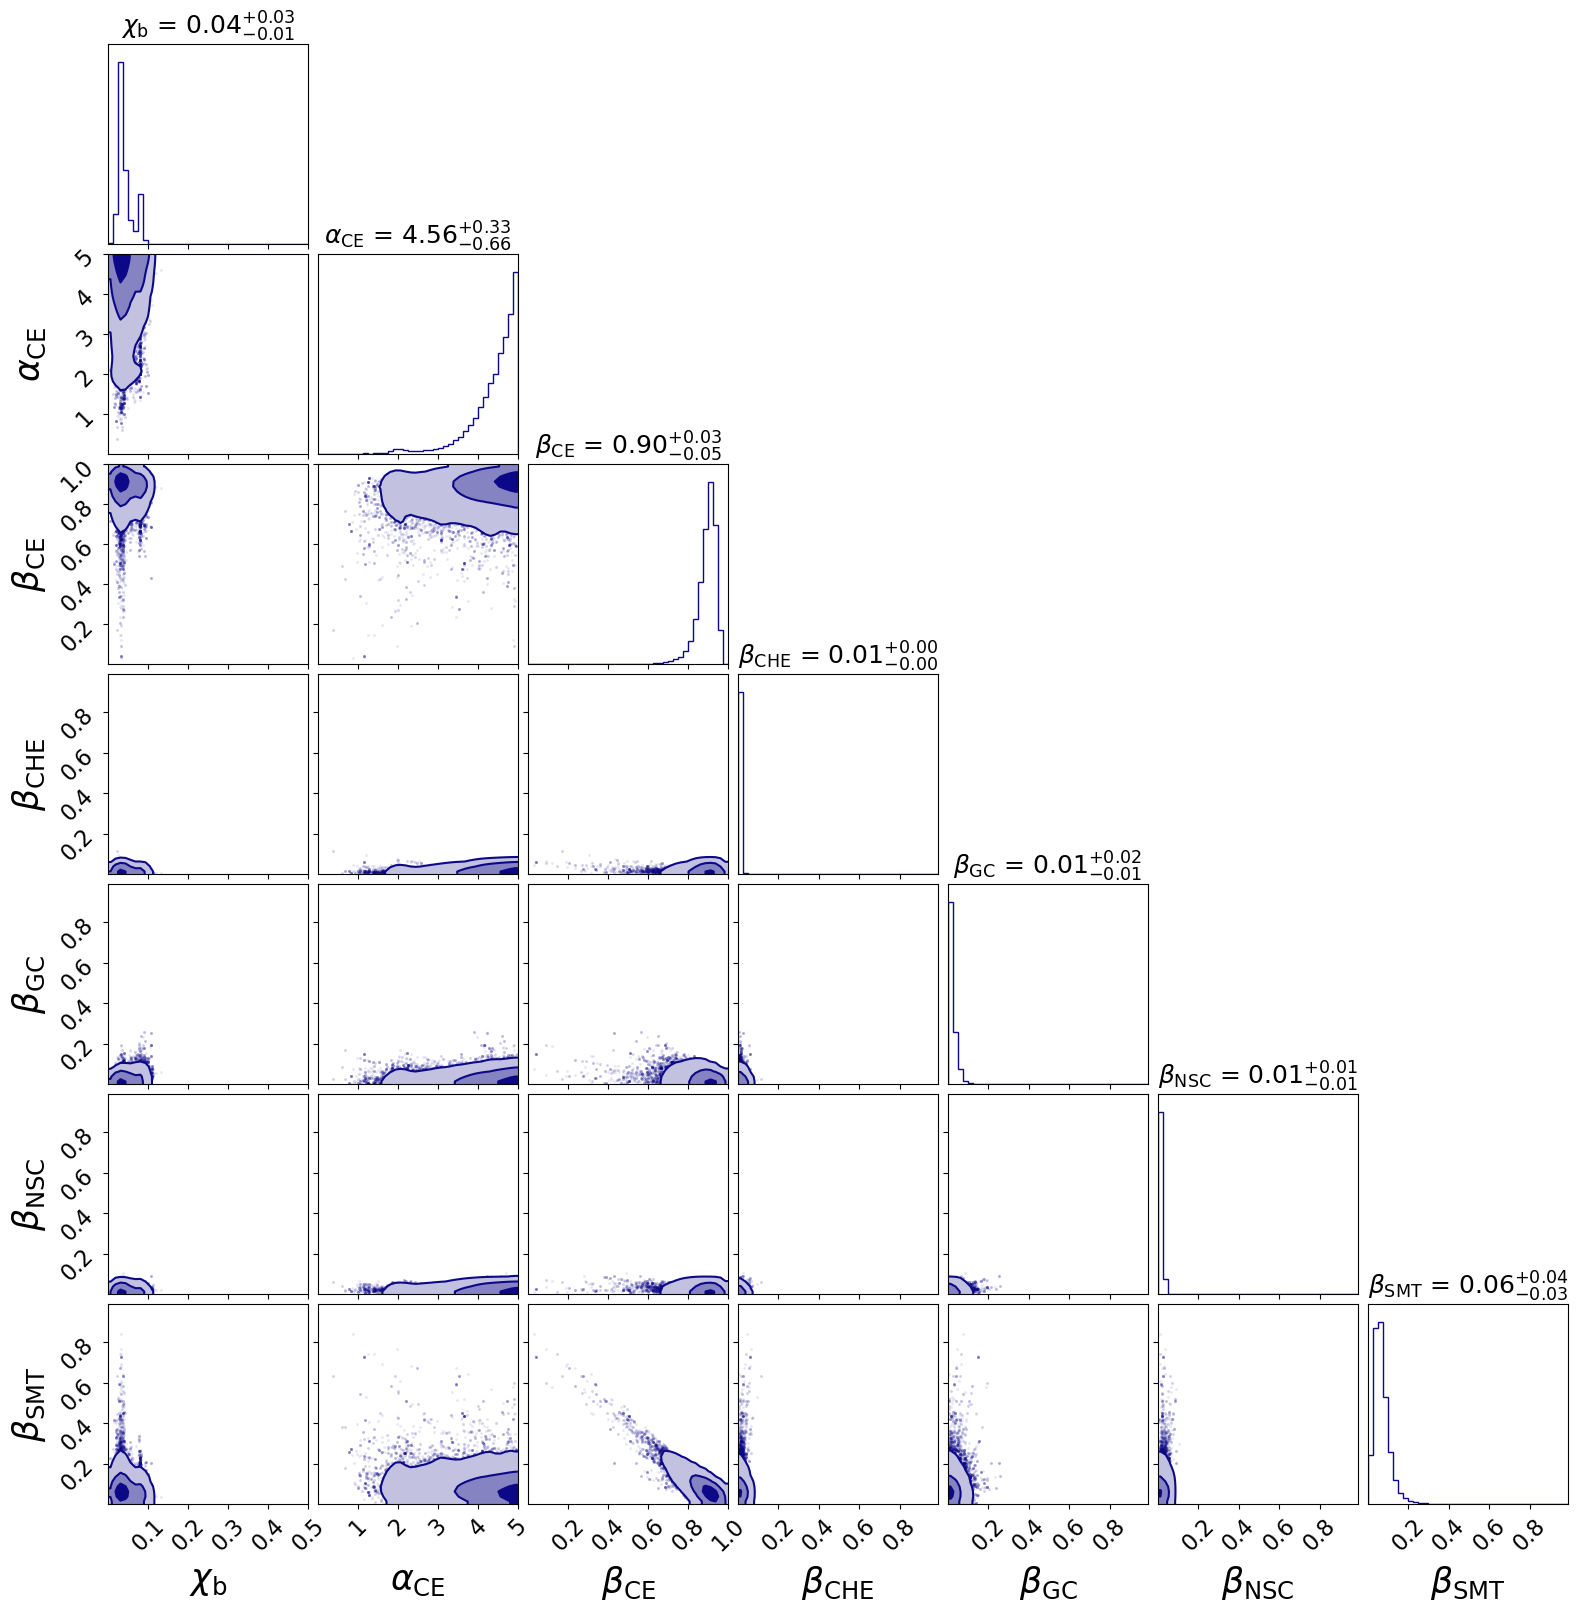

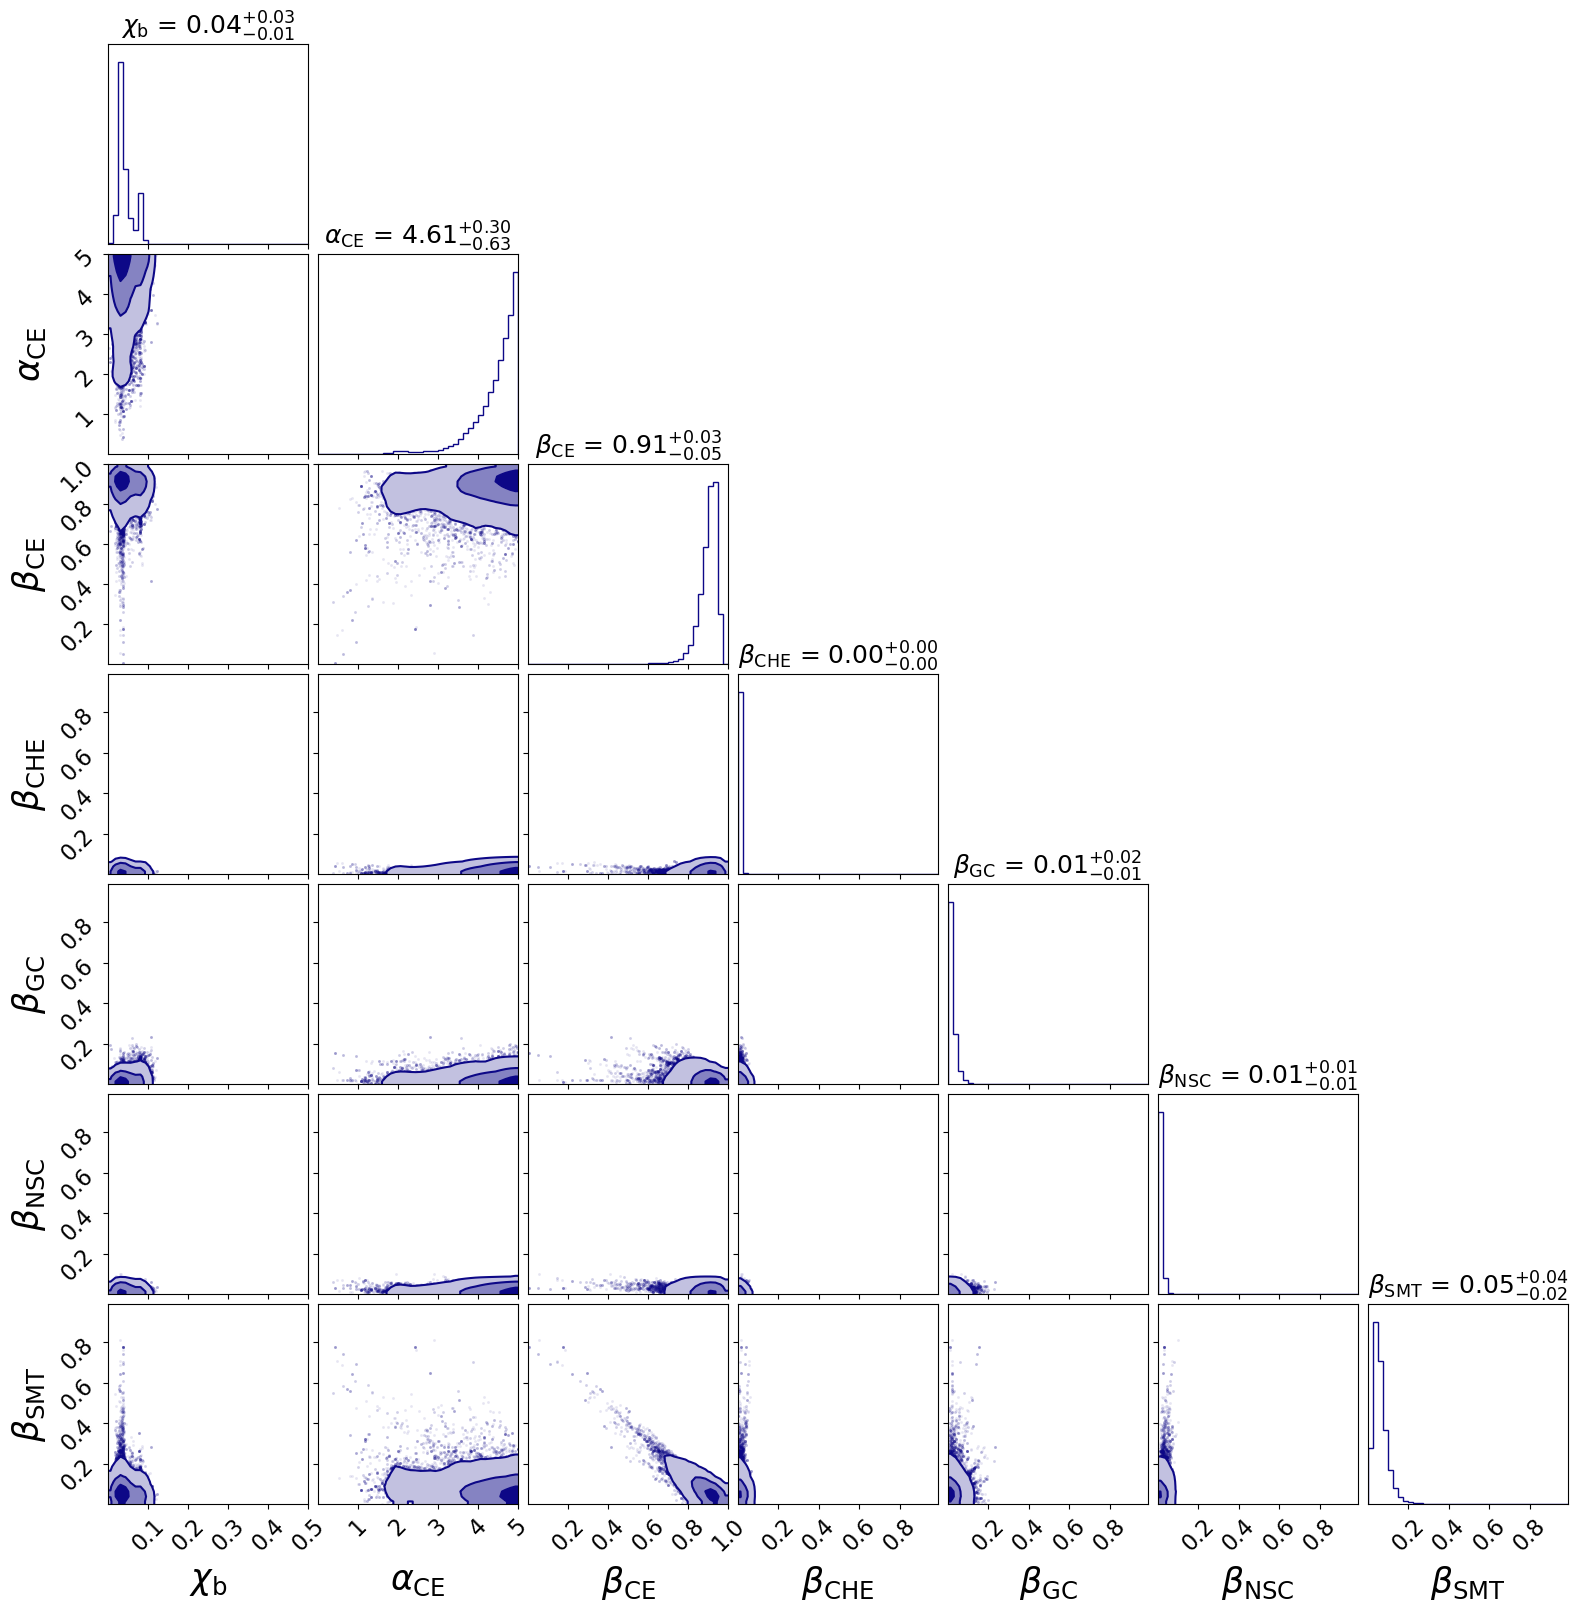

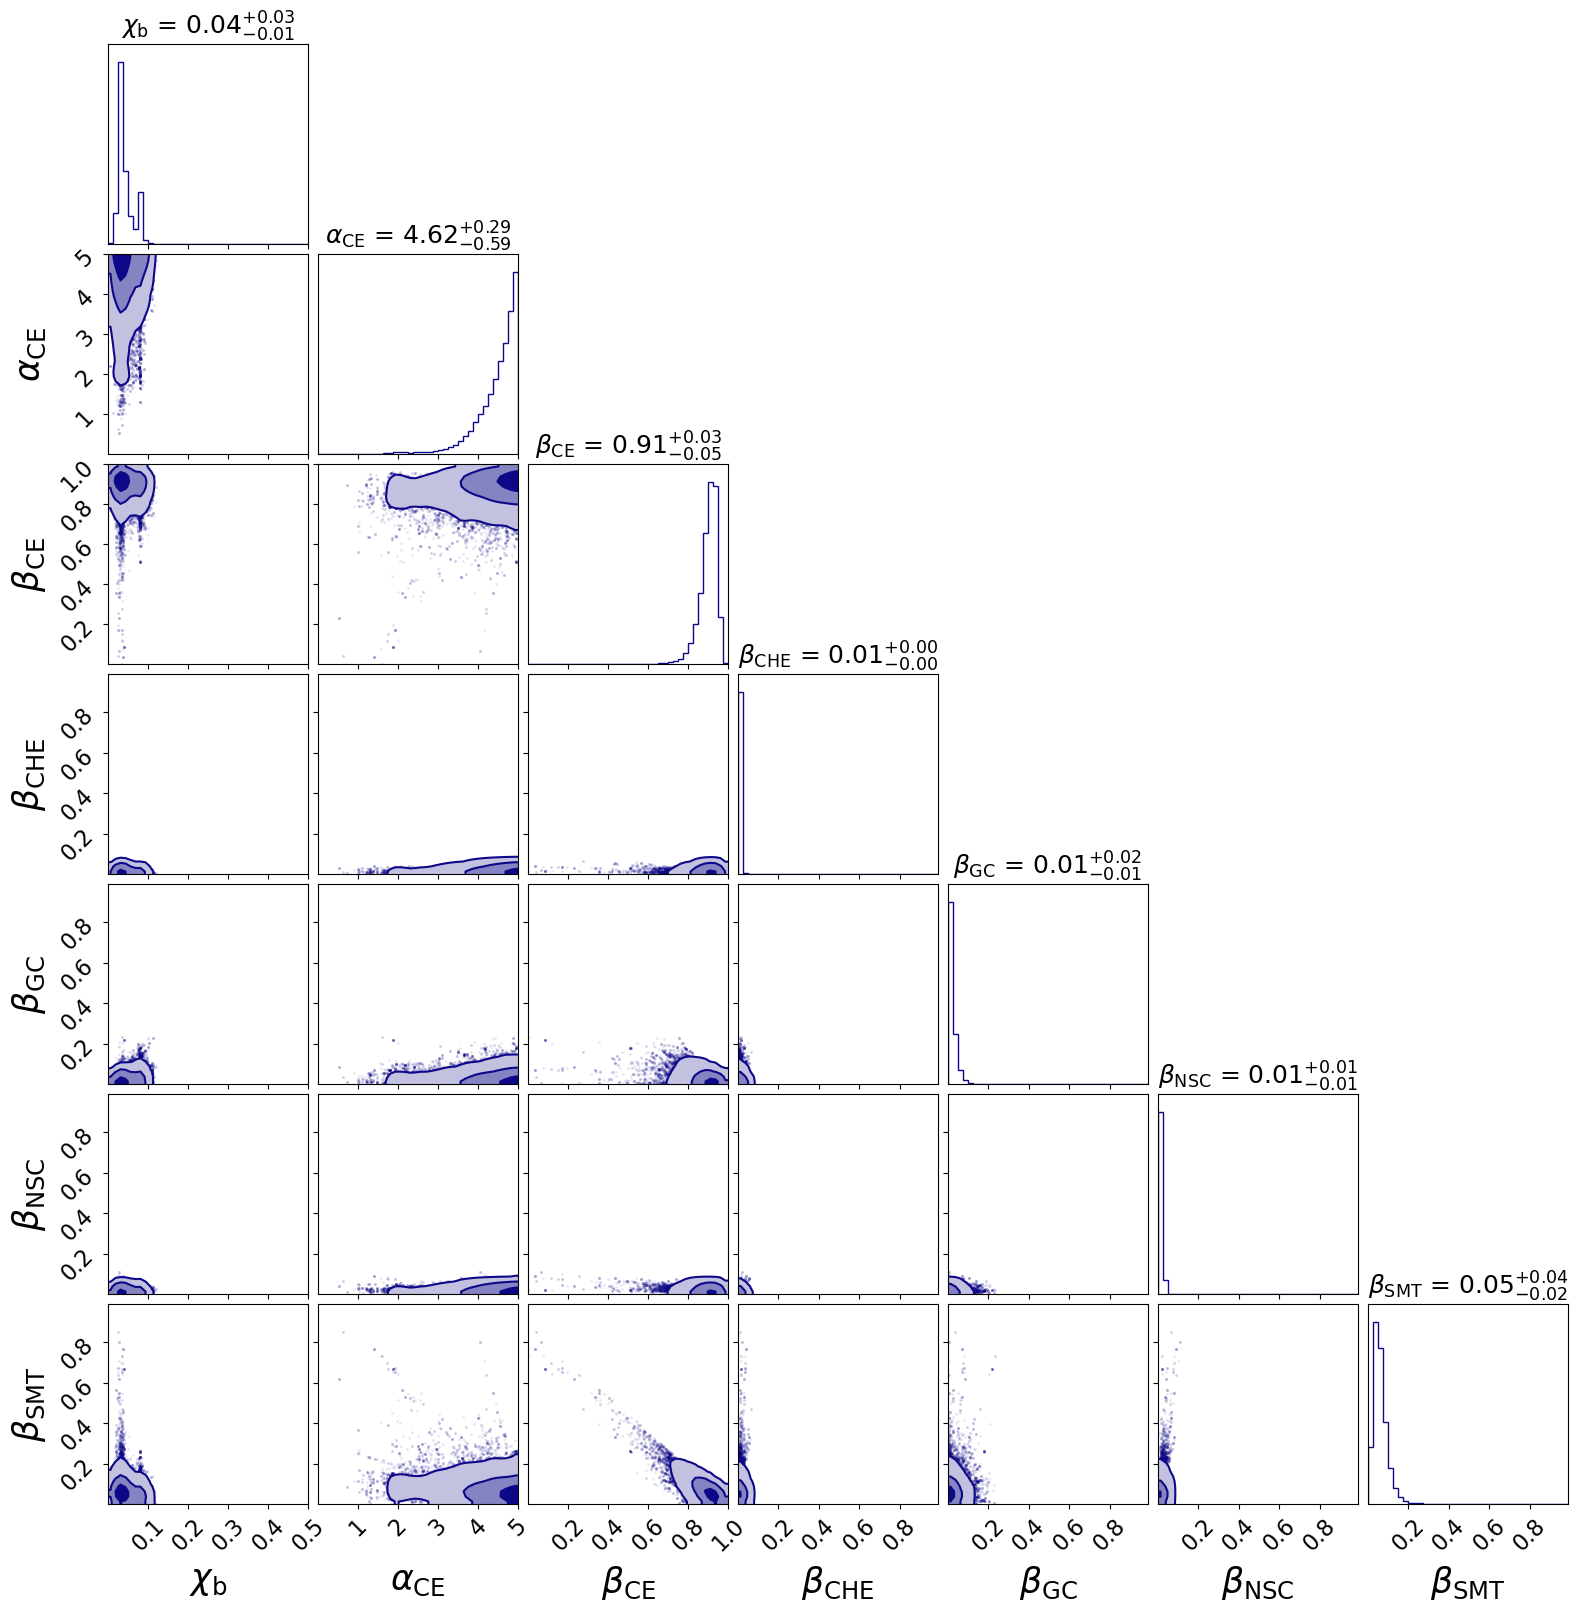

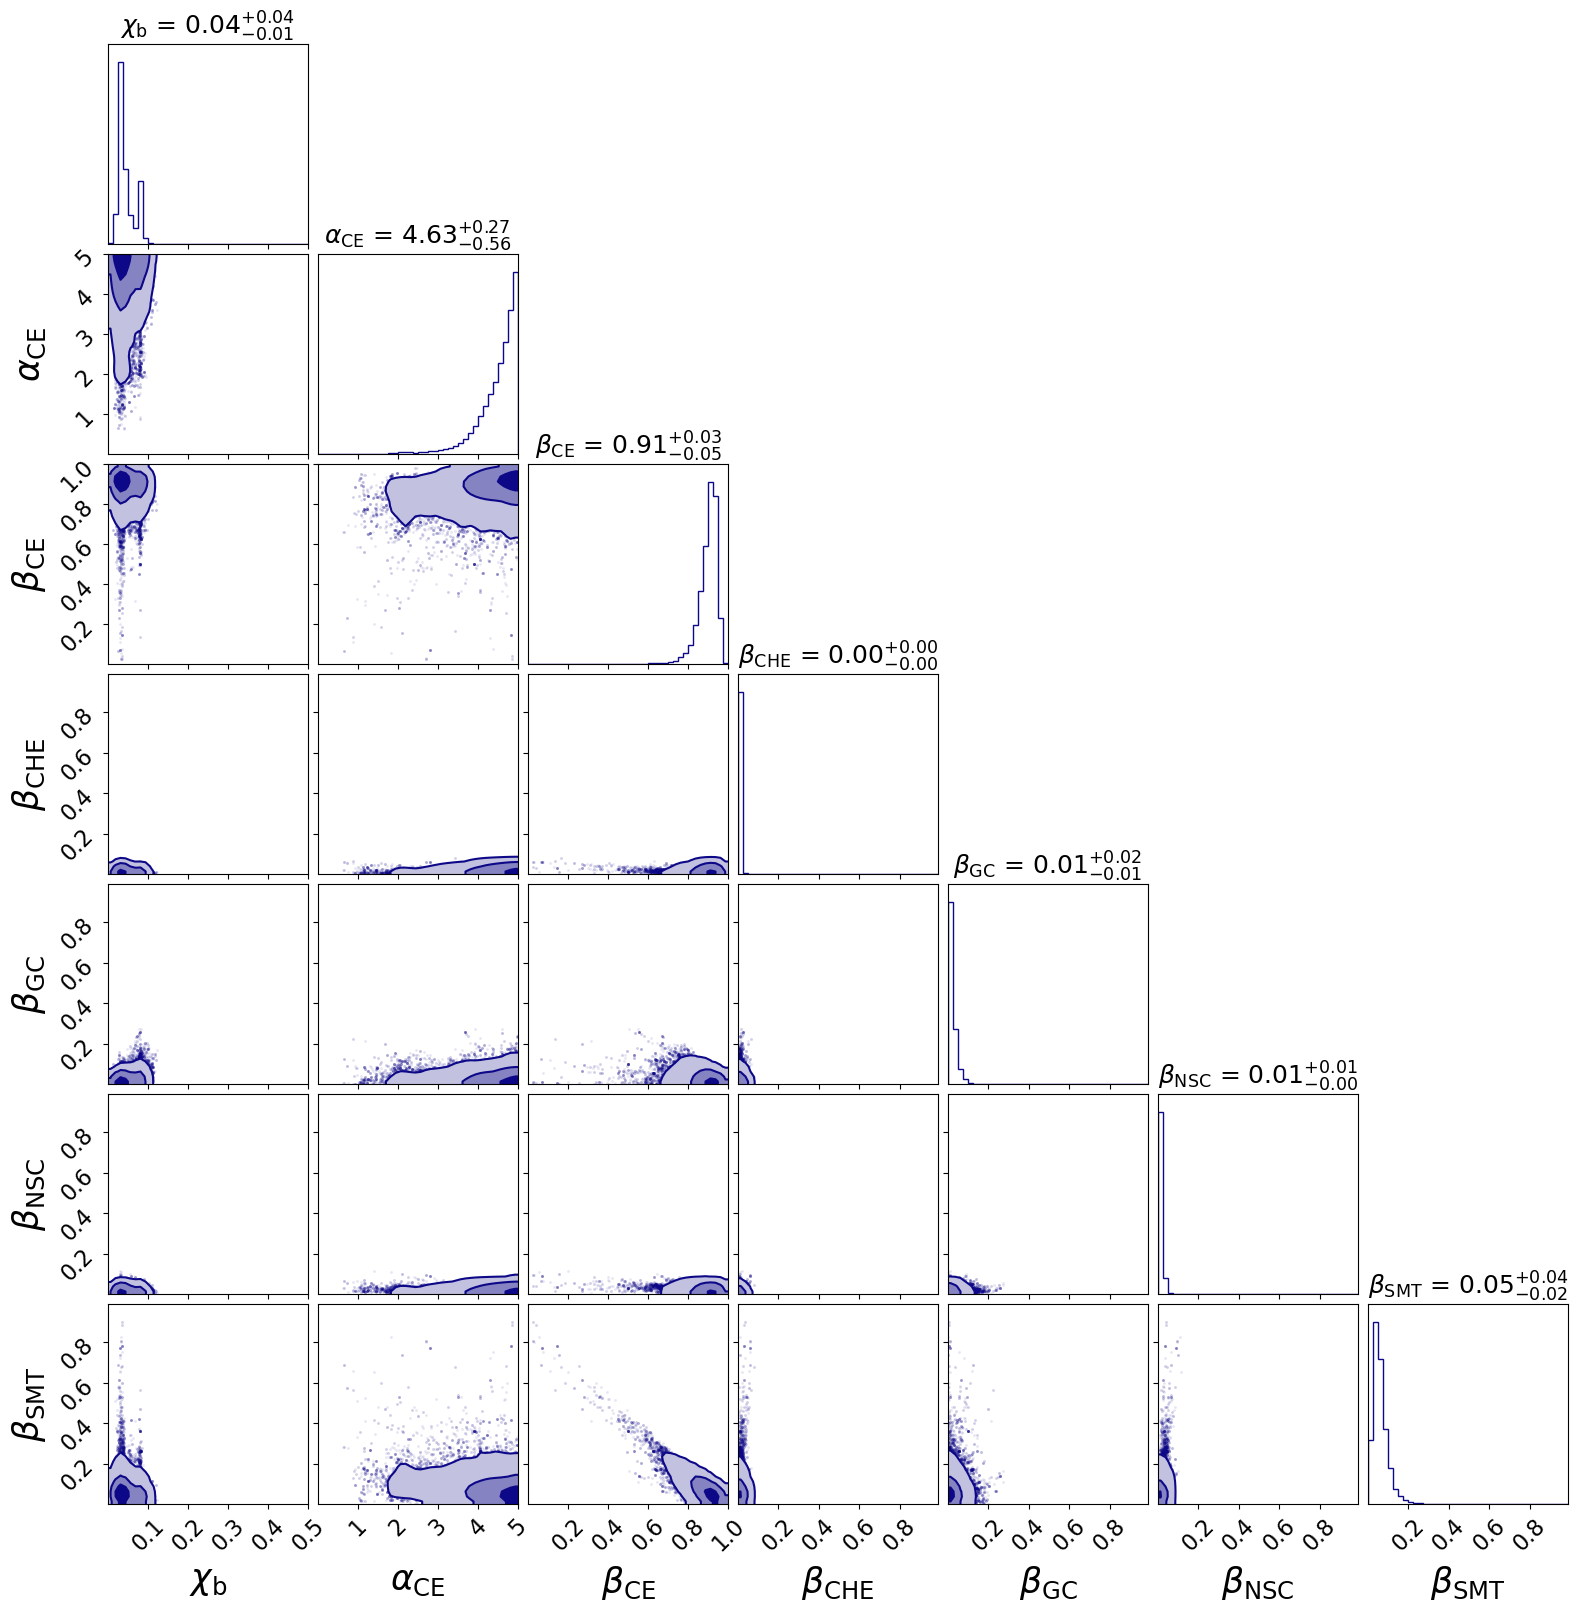

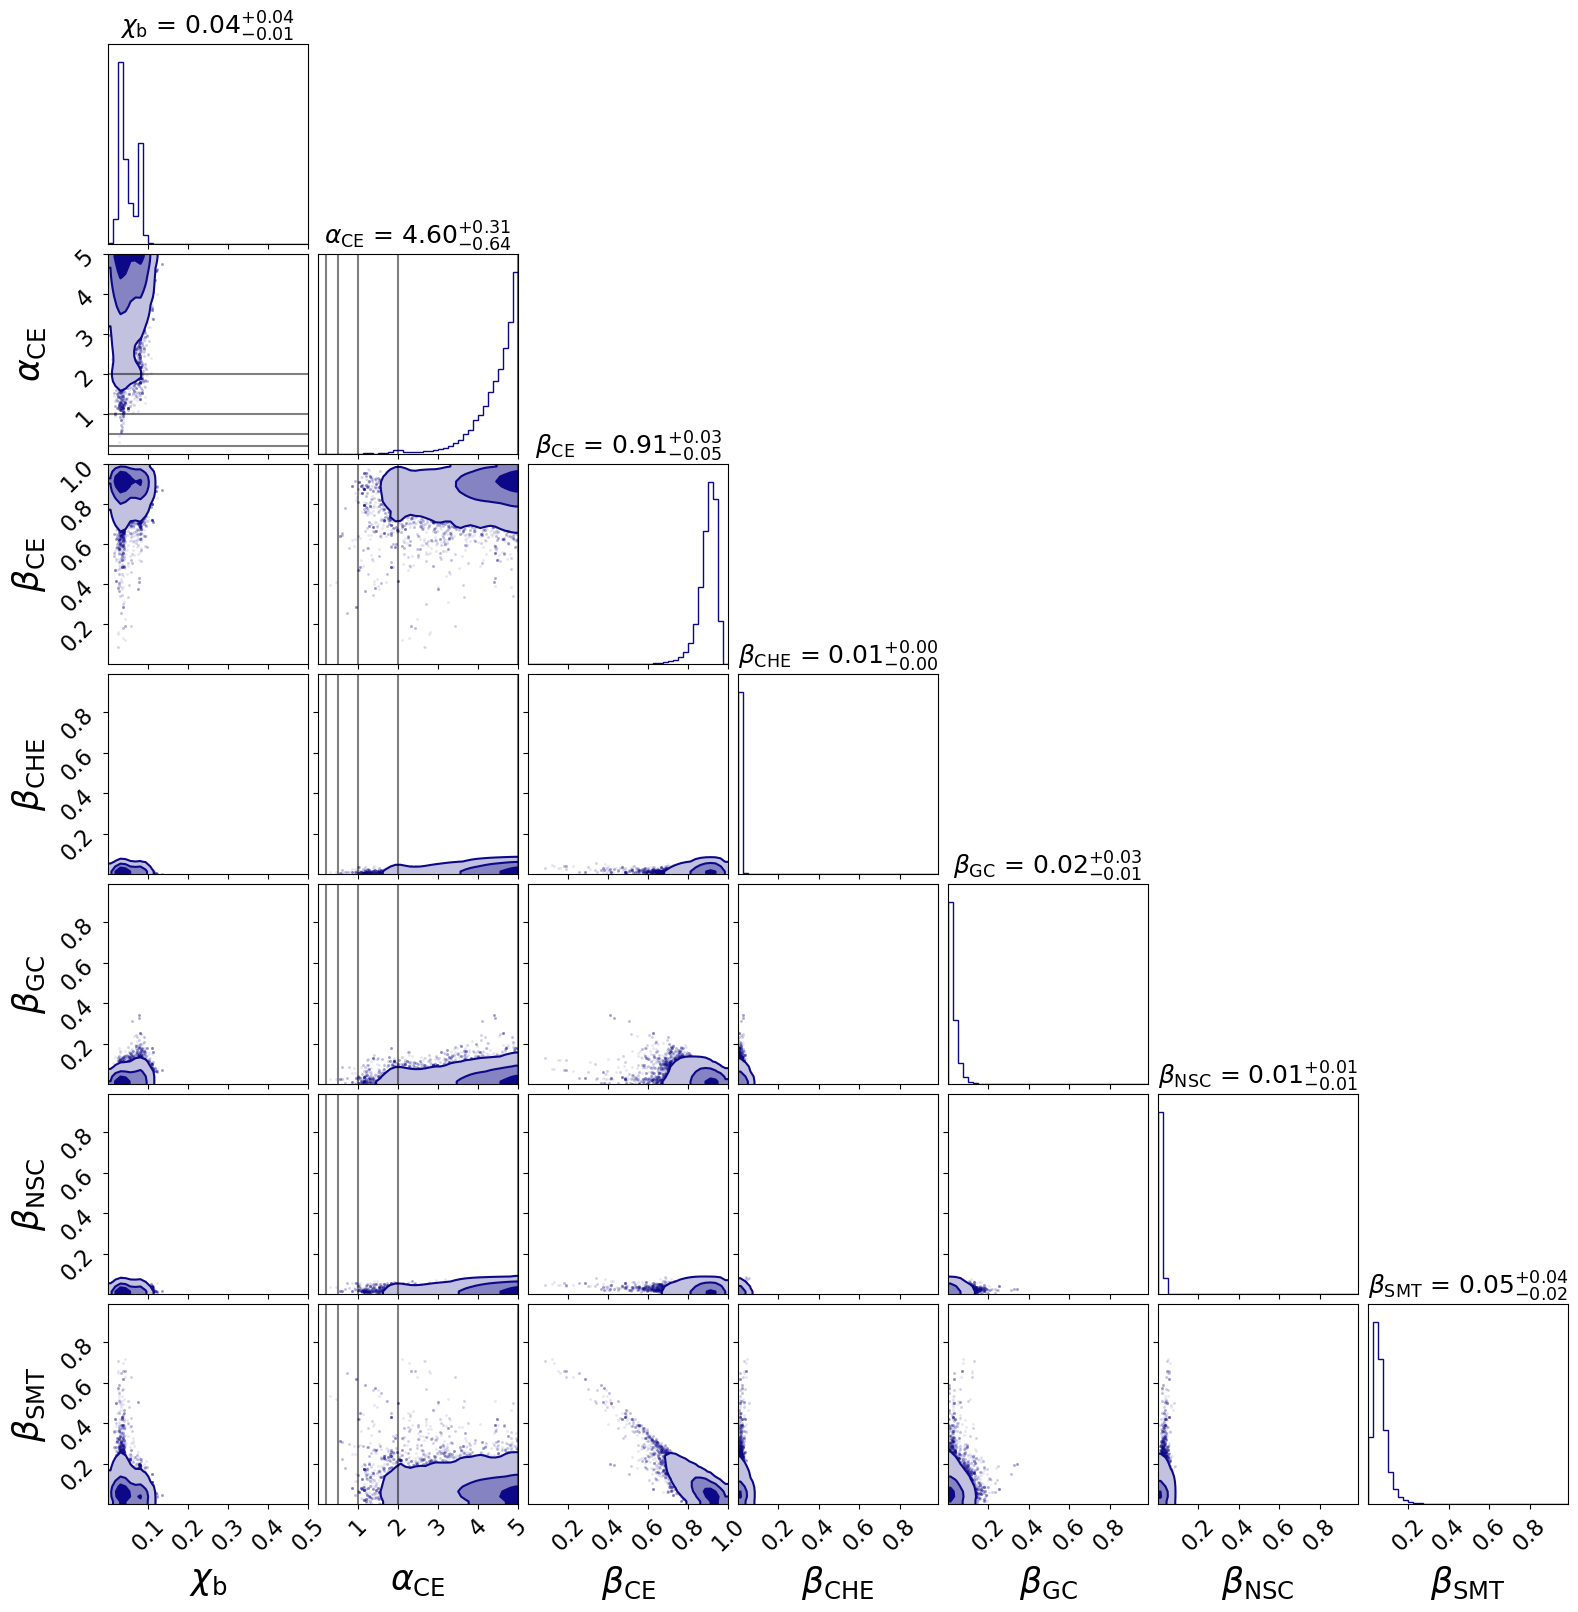

In [3]:
#corner plots of betas
plt.rcParams.update({'font.size': 16})

cmap = plt.colormaps['plasma']
# Take colors at regular intervals spanning the colormap.
colors = cmap(np.linspace(0, 1, 10))

corner_kwargs = dict(
    bins=40,
    smooth=0.9,
    color="royalblue",
    #quantiles=[0.16, 0.84],
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.0)),
    plot_density=True,
    plot_datapoints=True,
    fill_contours=True,
    show_titles=True,
    hist_kwargs=dict(density=True),
    label_kwargs=dict(fontsize=25),
    title_kwargs=dict(fontsize=18),
    labels=[r'$\chi_\mathrm{b}$', r'$\alpha_\mathrm{CE}$',r'$\beta_{\mathrm{CE}}$',r'$\beta_{\mathrm{CHE}}$',r'$\beta_{\mathrm{GC}}$',r'$\beta_{\mathrm{NSC}}$',r'$\beta_{\mathrm{SMT}}$'],
    range = [(0.,.5),(0.,5.),(0.,1.),(0.,.99),(0.,.99),(0.,.99),(0.,.99)]
)

i=0
for i, result in enumerate(['/PATH/TO/cont_GWTC3/output*.hdf5']):
    for result_file in glob.glob(result):
        flow_file = h5py.File(result_file, 'r')
        branching_fracs = np.array(flow_file['model_selection']['samples']['block0_values'])
        corner_kwargs['color'] = colors[i*2]
        corner_kwargs["hist_kwargs"]["color"] = colors[i*2]
        if i == 0:
            fig_data = corner.corner(branching_fracs, **corner_kwargs)
        else:
            corner.corner(branching_fracs, fig=fig_data, **corner_kwargs)



for a in alpha:
    corner.overplot_lines(fig_data, [None, a, None, None, None, None, None], color='black', alpha=0.5)
#fig_data = corner.corner(dirichlet.pdf(np.ones(5)*0.2, np.ones(5)), fig=fig_data, **corner_kwargs_kde)
#fig_data.savefig('/Users/stormcolloms/Documents/PhD/Project_work/AMAZE_model_selection/rns/Flows_200324_contcorrectalpha/plots/full_posteriors_corner_cont.pdf')

Text(0.5, 0, 'chi_b')

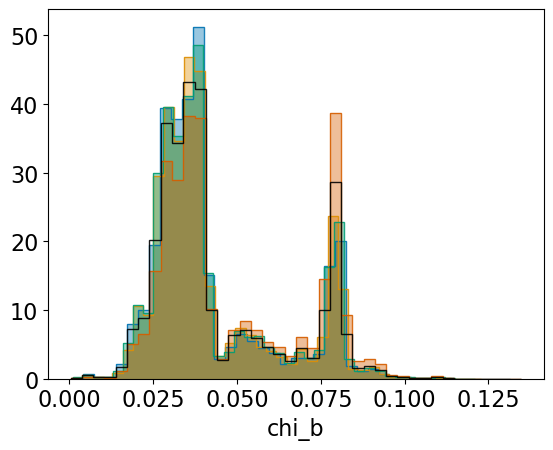

In [4]:
i=0
all_samples = np.array([])
colors = sns.color_palette("colorblind", n_colors=10)

for result_file in glob.glob('/PATH/TO/cont_GWTC3/output*.hdf5'):
    flow_file = h5py.File(result_file, 'r')
    branching_fracs = np.array(flow_file['model_selection']['samples']['block0_values'])
    plt.hist(branching_fracs[:,0], bins=40, alpha=0.4, histtype='stepfilled', color=colors[i], density=1)
    plt.hist(branching_fracs[:,0], bins=40, alpha=0.9, histtype='step', color=colors[i], density=1)
    i+=1
    all_samples = np.append(all_samples, branching_fracs)

all_samples = np.reshape(all_samples, (-1, 7))
plt.hist(all_samples[:,0], bins=40, alpha=0.9, histtype='step', color='black',  density=1)
plt.xlabel('chi_b')


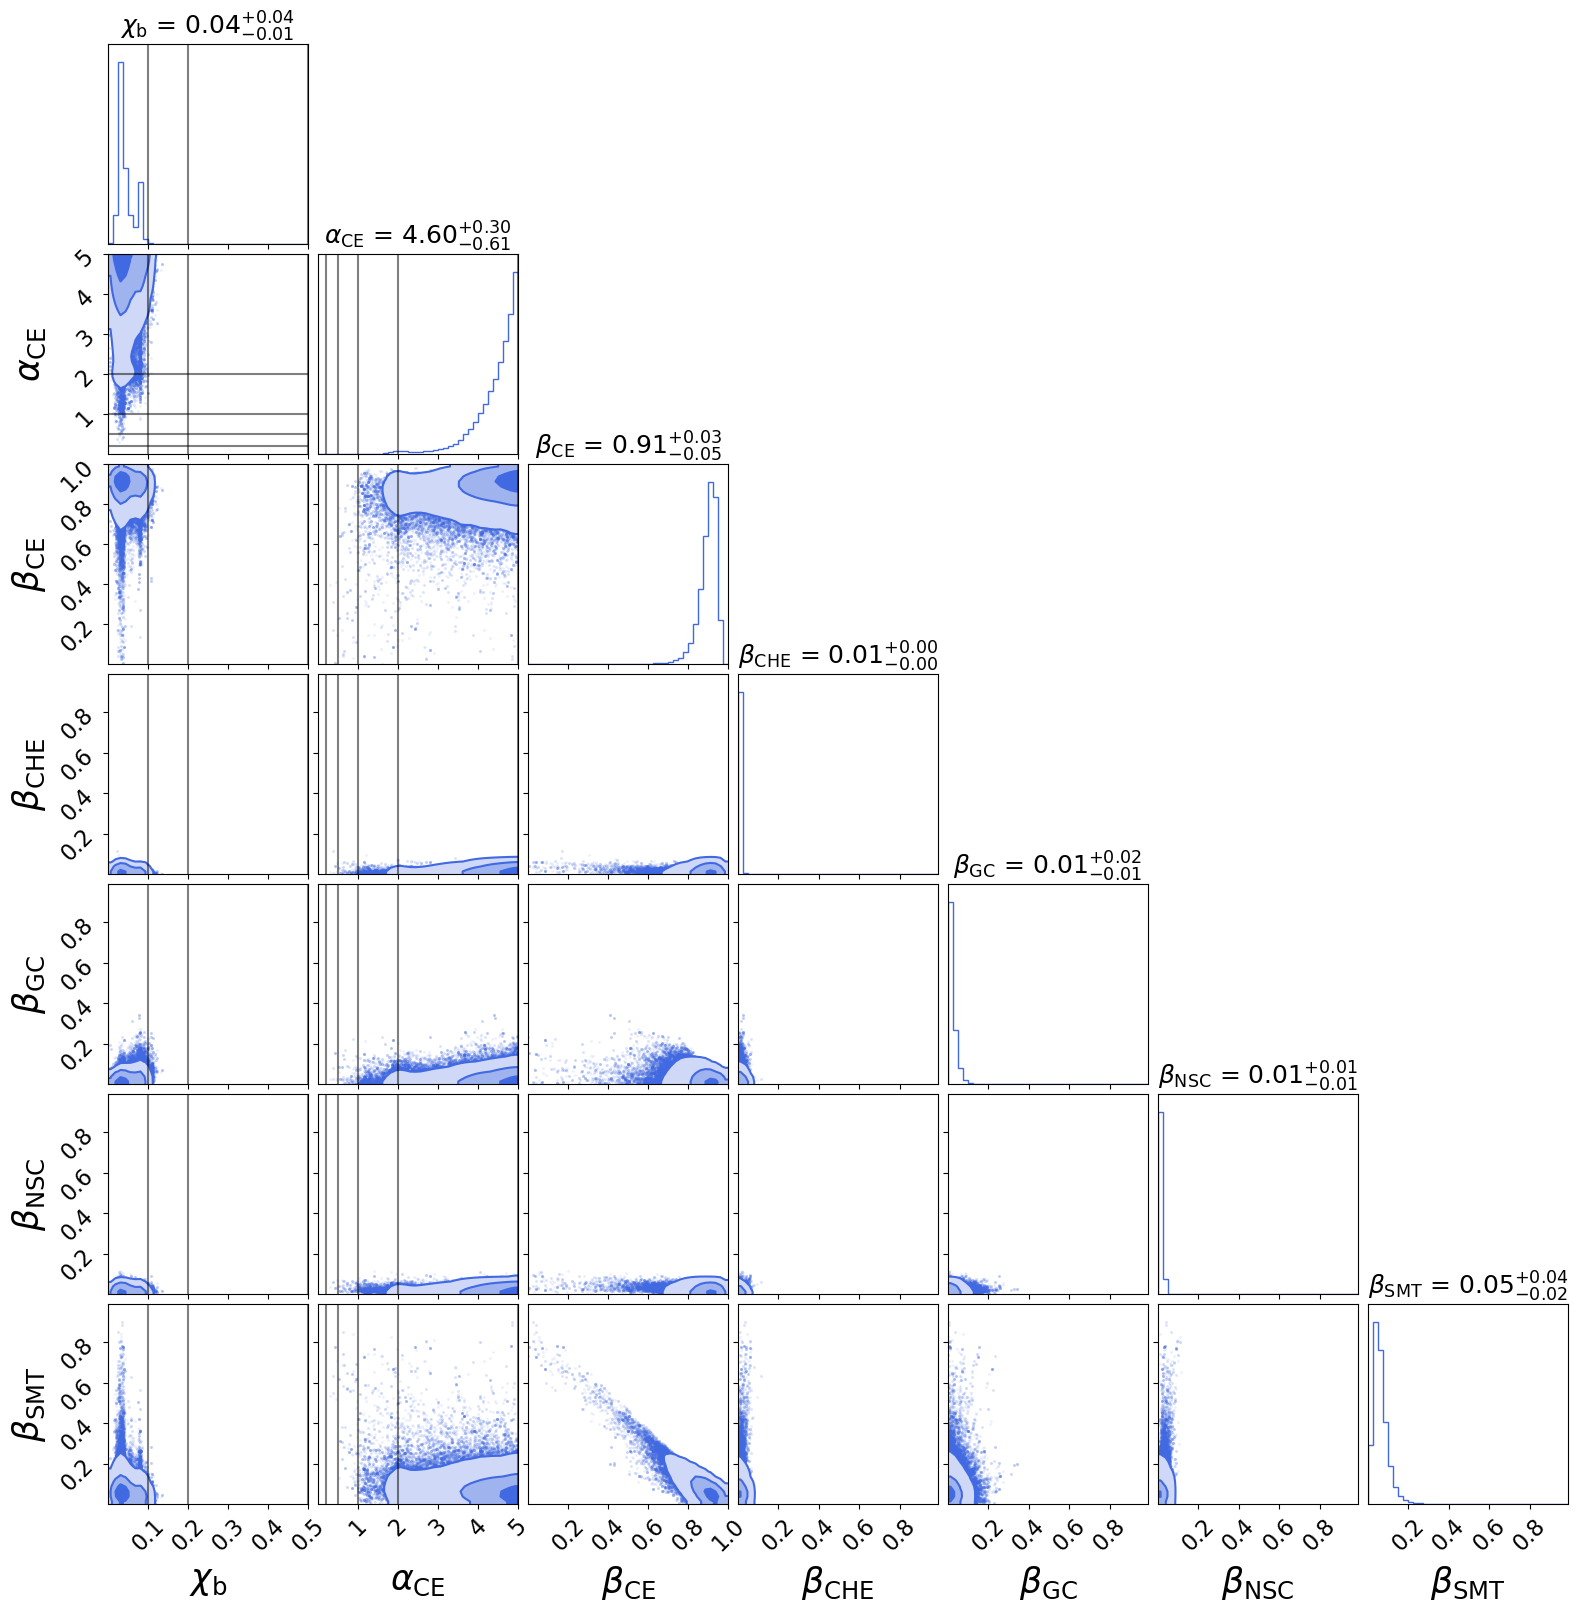

In [3]:
#corner plot of all samples for all run instances
plt.rcParams.update({'font.size': 16})


corner_kwargs = dict(
    bins=40,
    smooth=0.9,
    color="royalblue",
    #quantiles=[0.16, 0.84],
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.0)),
    plot_density=True,
    plot_datapoints=True,
    fill_contours=True,
    show_titles=True,
    hist_kwargs=dict(density=True),
    label_kwargs=dict(fontsize=25),
    title_kwargs=dict(fontsize=18),
    labels=[r'$\chi_\mathrm{b}$', r'$\alpha_\mathrm{CE}$',r'$\beta_{\mathrm{CE}}$',r'$\beta_{\mathrm{CHE}}$',r'$\beta_{\mathrm{GC}}$',r'$\beta_{\mathrm{NSC}}$',r'$\beta_{\mathrm{SMT}}$'],
    range = [(0.,.5),(0.,5.),(0.,1.),(0.,.99),(0.,.99),(0.,.99),(0.,.99)]
)

all_samples = np.array([])

for result_file in glob.glob('/PATH/TO/cont_GWTC3/output*.hdf5'):
    flow_file = h5py.File(result_file, 'r')
    result_samps = np.array(flow_file['model_selection']['samples']['block0_values'])
    all_samples = np.append(all_samples, result_samps)

all_samples = np.reshape(all_samples, (-1, 7))
fig_result = corner.corner(all_samples, **corner_kwargs)

for a in alpha:
    corner.overplot_lines(fig_result, [None, a, None, None, None, None, None], color='black', alpha=0.5)
for chi in chi_b:
    corner.overplot_lines(fig_result, [chi, None, None, None, None, None, None], color='black', alpha=0.5)
#fig_data = corner.corner(dirichlet.pdf(np.ones(5)*0.2, np.ones(5)), fig=fig_data, **corner_kwargs_kde)
#fig_data.savefig('/Users/stormcolloms/Documents/PhD/Project_work/AMAZE_model_selection/rns/Flows_200324_contcorrectalpha/plots/full_posteriors_corner_cont.pdf')

In [4]:
_labels_dict = {"mchirp": r"$\mathcal{M}$ /$M_{\odot}$", "q": r"$q$", \
"chieff": r"$\chi_{\rm eff}$", "z": r"$z$", "chi00": r"$\chi_\mathrm{b}=0.0$", \
"chi01": r"$\chi_\mathrm{b}=0.1$", "chi02": r"$\chi_\mathrm{b}=0.2$", \
"chi05": r"$\chi_\mathrm{b}=0.5$", "alpha02": r"$\alpha_\mathrm{CE}=0.2$", \
"alpha05": r"$\alpha_\mathrm{CE}=0.5$", "alpha10": r"$\alpha_\mathrm{CE}=1.0$", \
"alpha20": r"$\alpha_\mathrm{CE}=2.0$", "alpha50": r"$\alpha_\mathrm{CE}=5.0$", \
"CE": r"$\texttt{CE}$", "CHE": r"$\texttt{CHE}$", "GC": r"$\texttt{GC}$", \
"NSC": r"$\texttt{NSC}$", "SMT": r"$\texttt{SMT}$", \
"chi_b": r"$\chi_\mathrm{b}$", "alpha_CE": r"$\alpha_\mathrm{CE}$"}

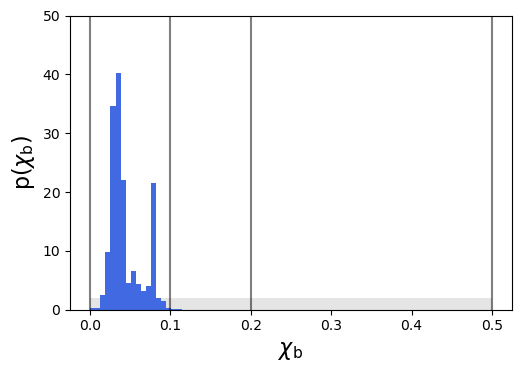

In [5]:
#1D chi_b posterior for presentation
chib_p0 =  np.random.uniform(0, 0.5, size=100000)
plt.rcParams['figure.figsize'] = [5.5, 4]
plt.rcParams["figure.facecolor"]=  (1.0, 0.0, 0.0, 0.0)

plt.hist(all_samples[:,0], density=True, color='royalblue', bins=np.linspace(0,0.5,80))
plt.hist(chib_p0, color='grey', bins=1, alpha=0.2, density=True, zorder=-1000)
plt.vlines(chi_b, 0, 50, color='black', alpha=0.5)
plt.ylim(1e-3,100)
plt.autoscale(tight=True, axis='y')
plt.xlabel(_labels_dict['chi_b'])
plt.ylabel('p('+_labels_dict['chi_b']+')')
plt.tick_params(labelsize=10)
#plt.yscale('log')
plt.tight_layout()
#plt.savefig('chi_b_hist_pres.png', transparent=True)

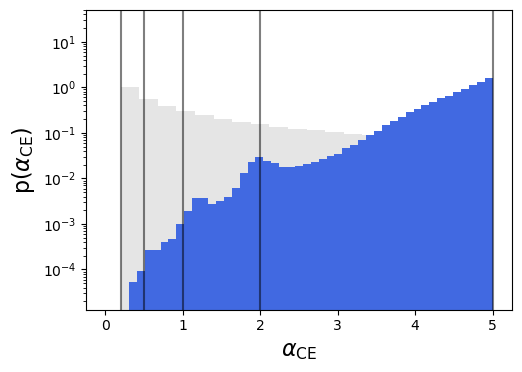

In [41]:
#1D alphaCE posterior for presentation
alphaCE_p0 =  loguniform.rvs(alpha[0], alpha[-1], size=100000)
plt.rcParams['figure.figsize'] = [5.5, 4]
plt.rcParams["figure.facecolor"]=  (1.0, 0.0, 0.0, 0.0)

plt.hist(all_samples[:,1], density=True, color='royalblue', bins=np.linspace(0,5.,50))
plt.hist(alphaCE_p0, color='grey', bins=20, alpha=0.2, density=True, zorder=-1000)
plt.vlines(alpha, 0, 50, color='black', alpha=0.5)
plt.autoscale(tight=True, axis='y')
plt.xlabel(_labels_dict['alpha_CE'])
plt.ylabel('p('+_labels_dict['alpha_CE']+')')
plt.tick_params(labelsize=10)
plt.yscale('log')
plt.tight_layout()
#plt.savefig('alphaCE_hist_pres.png', transparent=True)

## Detectable Branching Fractions
Caculated using underlying branching fraction and detection efficiencies

In [4]:
#load flows
file_path='/PATH/TO/models_reduced.hdf5'
params = ['mchirp','q', 'chieff', 'z']
channels =['CE', 'CHE', 'GC', 'NSC', 'SMT']

model_names, flow = read_models.get_models(file_path, channels, params, use_flows=True, device='cpu',\
     sensitivity='midhighlatelow_network', use_unityweights=False)

100%|██████████| 5/5 [01:31<00:00, 18.39s/it]


In [6]:
all_samples[:5,:]

array([[0.03246563, 4.32992828, 0.74112362, 0.00826584, 0.01053955,
        0.02021594, 0.21985505],
       [0.03246563, 4.32992828, 0.74112362, 0.00826584, 0.01053955,
        0.02021594, 0.21985505],
       [0.03264119, 4.3118685 , 0.72935655, 0.00840761, 0.01053634,
        0.0209062 , 0.23079331],
       [0.03264119, 4.3118685 , 0.72935655, 0.00840761, 0.01053634,
        0.0209062 , 0.23079331],
       [0.03264272, 4.31187509, 0.72936001, 0.00840776, 0.0105364 ,
        0.0209057 , 0.23079013]])

In [10]:
alphas = np.zeros((all_samples.shape[0], len(channels)))
#get alpha for 5 channels given chi_b, alpha_CE in each sample
for i, samp in enumerate(tqdm(all_samples)):
    for cidx, chnl in enumerate(channels):
        smdl = flow[chnl]
        if chnl == 'CE':
            alphas[i, cidx] = smdl.get_alpha([[samp[0], np.log(samp[1])]])
        else:
            alphas[i, cidx] = smdl.get_alpha([samp[:1][0], 1.])

  0%|          | 0/750000 [00:00<?, ?it/s]/tmp/ipykernel_1054641/3345448861.py:7: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  alphas[i, cidx] = smdl.get_alpha([[samp[0], np.log(samp[1])]])
/tmp/ipykernel_1054641/3345448861.py:9: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  alphas[i, cidx] = smdl.get_alpha([samp[:1][0], 1.])
100%|██████████| 750000/750000 [21:06<00:00, 592.12it/s]


In [11]:
converted_betas = (all_samples[:,2:] * alphas)
#divide by sum across channels
converted_betas /= converted_betas.sum(axis=1, keepdims=True)

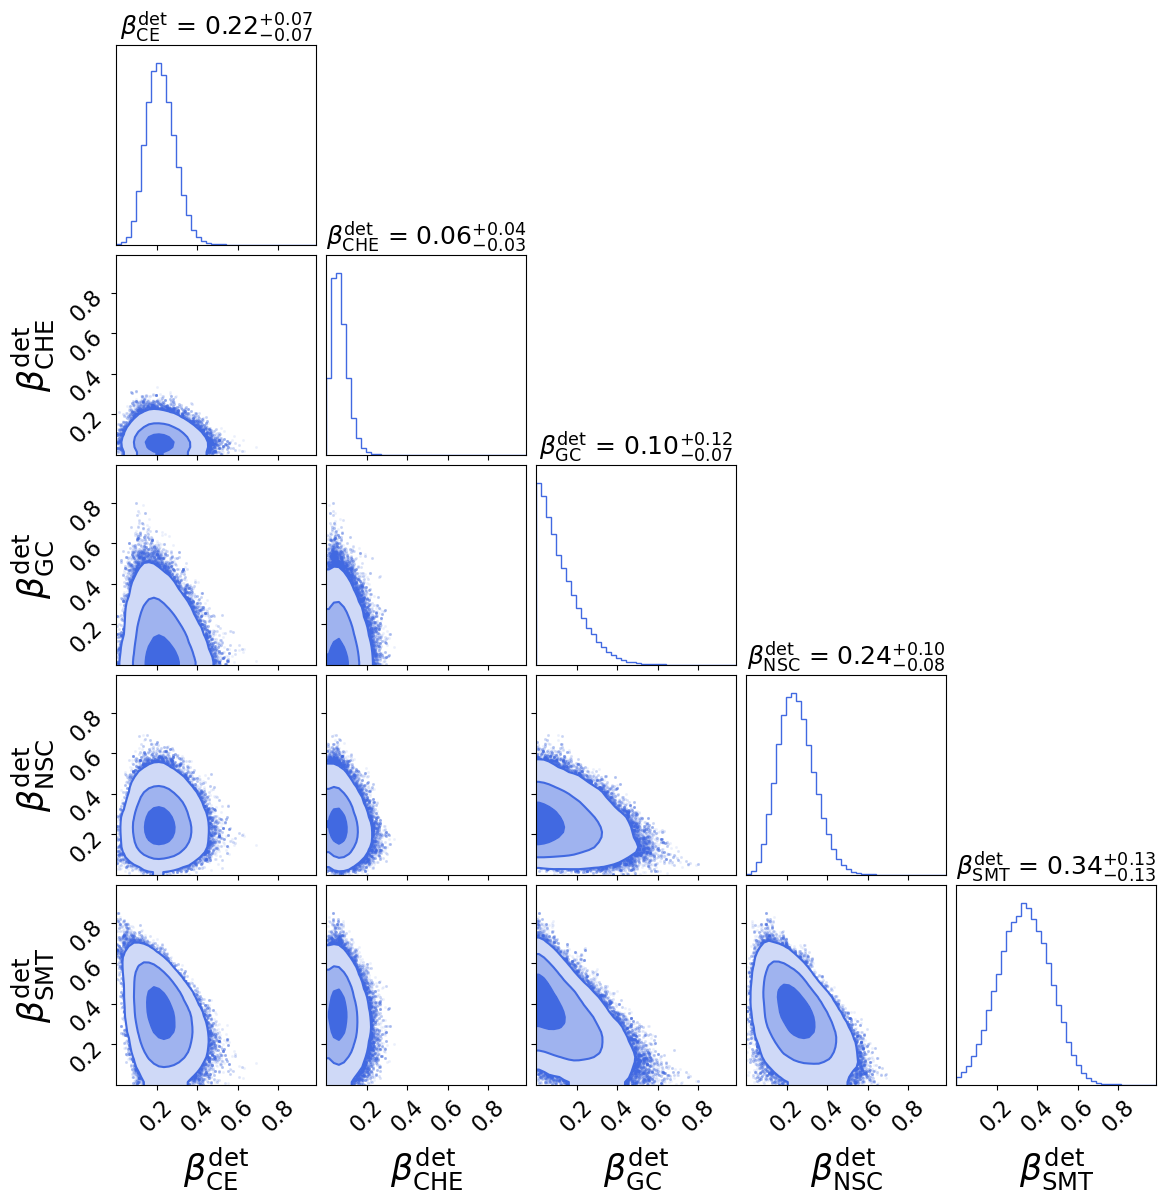

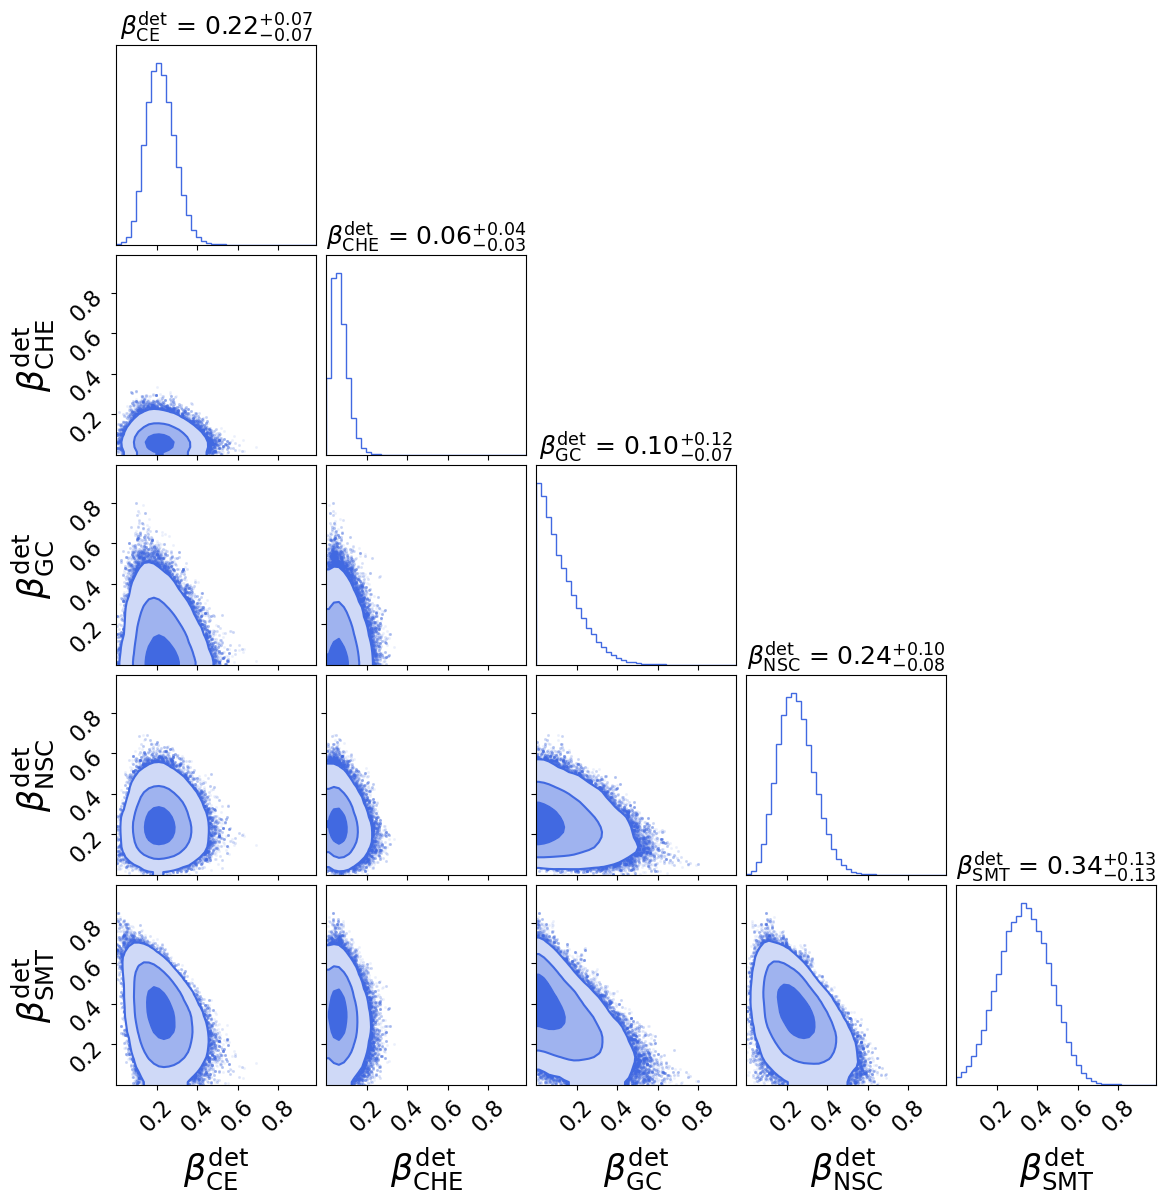

In [12]:
corner_kwargs_det = dict(
    bins=40,
    smooth=0.9,
    color="royalblue",
    #quantiles=[0.16, 0.84],
    levels=(1 - np.exp(-0.5), 1 - np.exp(-2), 1 - np.exp(-9 / 2.0)),
    plot_density=True,
    plot_datapoints=True,
    fill_contours=True,
    show_titles=True,
    hist_kwargs=dict(density=True),
    label_kwargs=dict(fontsize=25),
    title_kwargs=dict(fontsize=18),
    labels=[r'$\beta_{\mathrm{CE}}^{\mathrm{det}}$',r'$\beta_{\mathrm{CHE}}^{\mathrm{det}}$',r'$\beta_{\mathrm{GC}}^{\mathrm{det}}$',r'$\beta_{\mathrm{NSC}}^{\mathrm{det}}$',r'$\beta_{\mathrm{SMT}}^{\mathrm{det}}$'],
    #labels=[r'$\alpha_CE$',r'$\Beta_CE$',r'$\Beta_CHE$',r'$\Beta_GC$',r'$\Beta_NSC$',r'$\Beta_SMT$'],
    range = [(0.,.99),(0.,.99),(0.,.99),(0.,.99),(0.,.99)]
)
corner.corner(converted_betas, **corner_kwargs_det)